
# CSCI 408 — BLIP: Raw vs Current vs Fine-Tuned

## Goal

Compare **three versions of the same BLIP report-generation architecture** on the same 30 unseen Indiana Chest X-ray examples:

1. **Raw / randomized BLIP**  
   Same architecture/configuration as the current model, but initialized with random weights, then trained on the 270-example training split.

2. **Current model (baseline)**  
   `nathansutton/generate-cxr` exactly as used in the current project, with **no extra training on our 270 examples**.

3. **Fine-tuned current model**  
   Start from `nathansutton/generate-cxr`, then fine-tune it on the **same 270-example training split** used for the raw model.

### Dataset protocol

- 3 classes: `Normal`, `Cardiomegaly`, `Pleural Effusion`
- 100 examples per class = **300 total**
- **270 training** examples = 90 per class
- **30 testing** examples = 10 per class
- The same fixed test set is used for all three models.
- Test images are never used for training.

### Important interpretation note

This notebook compares generated text using **automatic text-similarity metrics** and side-by-side outputs.  
It is **not a clinical validation** and does not claim that a model is medically correct. We are not radiologists; the final “best model” statement is only an approximate comparison against the reference reports.



# CSCI 408 — BLIP: Raw vs Current vs Fine-Tuned — FIXED VERSION

## Goal

Compare **three versions of the same BLIP report-generation architecture** on the exact same 30 unseen Indiana Chest X-ray examples:

1. **Raw / randomized BLIP** — same architecture/configuration, random weights, trained on the fixed 270-example split.
2. **Current model (baseline)** — `nathansutton/generate-cxr`, no extra training on our 270 examples.
3. **Fine-tuned current model** — starts from `nathansutton/generate-cxr`, then fine-tuned on the same fixed 270 examples.

### What was fixed

- The notebook no longer requires downloading the full ~14 GB Indiana dataset to your PC.
- The exact `report_train_270.csv` and `report_test_30.csv` supplied for this project are embedded inside the notebook.
- On **Kaggle**, the notebook first uses a mounted Indiana dataset if you already attached it; otherwise it downloads **only the 300 required PNG files** into the temporary Kaggle runtime.
- On a local computer, it first checks `./images`; if the required images are absent, it can also fetch only those 300 files.
- Paths are automatic for Kaggle vs local Jupyter/VS Code.
- Output files are written to a dedicated results folder.
- Large model checkpoints are **not saved by default**, preventing several extra GB of disk usage.
- Training uses mixed precision on CUDA, gradient accumulation, and gradient checkpointing where supported.

### Recommended way to run

**Kaggle Notebook + GPU + Internet ON.**

You do not need to attach the full Indiana dataset. The notebook can fetch only the required 300 images into the temporary Kaggle session.

> This is a non-clinical research comparison. BLEU/ROUGE/BERTScore measure similarity to reference text, not medical safety or diagnostic correctness.


In [1]:

# Run once in a fresh Kaggle / Colab / Jupyter environment.
# Transformers v4 is intentionally pinned because this project uses BlipForConditionalGeneration.
%pip -q install "transformers>=4.45,<5" "huggingface_hub>=0.24" rouge-score bert-score nltk accelerate sentencepiece


Note: you may need to restart the kernel to use updated packages.



## 1. Imports and robust experiment configuration

The notebook auto-detects Kaggle vs local execution.

Generation settings intentionally stay close to the current project:
`max_new_tokens=120`, `num_beams=3`, `repetition_penalty=2.0`.


In [2]:

import os
import gc
import io
import time
import math
import json
import random
import shutil
import base64
import zlib
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from IPython.display import display

import torch
from torch.utils.data import Dataset, DataLoader

from huggingface_hub import hf_hub_download

from transformers import (
    BlipProcessor,
    BlipConfig,
    BlipForConditionalGeneration,
)
from transformers.optimization import Adafactor

from rouge_score import rouge_scorer
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from bert_score import score as bert_score

# ----------------------------
# Reproducibility
# ----------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    # Faster matrix multiplications on supported NVIDIA GPUs.
    torch.backends.cuda.matmul.allow_tf32 = True

# ----------------------------
# Environment / paths
# ----------------------------
IS_KAGGLE = Path("/kaggle/working").exists()

if IS_KAGGLE:
    WORK_DIR = Path("/kaggle/working/blip_3_model_comparison")
else:
    WORK_DIR = Path.cwd() / "blip_3_model_comparison"

WORK_DIR.mkdir(parents=True, exist_ok=True)

RESULT_DIR = WORK_DIR / "results"
RESULT_DIR.mkdir(parents=True, exist_ok=True)

# Temporary/selective image cache. On Kaggle this disappears with the session.
SELECTIVE_DATA_DIR = WORK_DIR / "iu_xray_300"
SELECTIVE_IMAGE_DIR = SELECTIVE_DATA_DIR / "images" / "images_normalized"

# If the full Kaggle dataset is already attached, use it directly and download nothing.
KAGGLE_IMAGE_CANDIDATES = [
    Path("/kaggle/input/chest-xrays-indiana-university/images/images_normalized"),
    Path("/kaggle/input/chest-xrays-indiana-university/images_normalized"),
]

# Local project layout from the original notebook.
LOCAL_IMAGE_CANDIDATES = [
    Path.cwd() / "images",
    Path.cwd() / "images" / "images_normalized",
]

# ----------------------------
# Remote source for SELECTIVE image download
# ----------------------------
HF_DATASET_ID = "sasi2004/chest-xrays-indiana-university"
HF_IMAGE_PREFIX = "images/images_normalized"

# ----------------------------
# Model
# ----------------------------
MODEL_ID = "nathansutton/generate-cxr"

# ----------------------------
# Fixed split
# ----------------------------
TRAIN_SIZE = 270
TEST_SIZE = 30

# ----------------------------
# Training
# ----------------------------
BATCH_SIZE = 1
GRAD_ACCUM_STEPS = 8

RAW_EPOCHS = 3
FINETUNE_EPOCHS = 3

RAW_LR = 1e-4
FINETUNE_LR = 1e-5
MAX_TEXT_LENGTH = 160

# Saving a ~0.5B model can consume multiple GB per checkpoint.
# Keep False unless you explicitly need reusable model weights.
SAVE_MODEL_CHECKPOINTS = False

# ----------------------------
# Generation
# ----------------------------
MAX_NEW_TOKENS = 120
NUM_BEAMS = 3
REPETITION_PENALTY = 2.0

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Environment:", "Kaggle" if IS_KAGGLE else "Local / other Jupyter")
print("Working directory:", WORK_DIR)
print("Results directory:", RESULT_DIR)
print("Device:", device)

if device.type != "cuda":
    print(
        "\nWARNING: A CUDA GPU is strongly recommended. "
        "Training a ~0.5B-parameter BLIP model on CPU is impractically slow."
    )
else:
    print("GPU:", torch.cuda.get_device_name(0))


c:\Users\danik\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Environment: Local / other Jupyter
Working directory: c:\Users\danik\Desktop\Проекты\Medical Image\blip_3_model_comparison
Results directory: c:\Users\danik\Desktop\Проекты\Medical Image\blip_3_model_comparison\results
Device: cpu




## 2. Load the exact fixed 270/30 split

The user's project split is embedded directly in this notebook.

That means:

- no dependence on `indiana_projections.csv` / `indiana_reports.csv` just to reconstruct the split;
- no accidental re-sampling;
- exactly the same 270 training and 30 testing examples every run;
- exactly 90/10 examples per class.


In [3]:

# Compressed copies of the exact project split CSVs.
# They decode to the original columns: image, y_label, y_report.
TRAIN_CSV_ZLIB_B64 = """..."""
TEST_CSV_ZLIB_B64 = """eNrVWk2T2zYSvbvK/wHls0YrUtJodEzGSa2r7KzL9qb2lgJJSEJMElyA1Fj59XndAD9FjSep2sPmMI45JNDofv36dcO6kEe1uPyWy0Tl+NOqytj69atov4t+e/fhbnW/Xt9Fq1W0zNJiWZXHxS/GFjJfvPlcyyRX4qSkrYXTf6iFKFSmpat1KXM8yU+mUXWtluIXI8xZ4TWVqULy3w8mxUupKZ3JdSZrbcqFqHLVWDxWh0Pj8EQYK6pSNYWpT8bKb8s3r1+t1/E9GRZt9/HdZrXadIY9SptpU6ijzC+LNz99k4X4byNzXV9Ergtdq0wkF3G6VLClrHXOmwpZZkJWmqzJjc1MrVNxsKas8aCy5neV0mtL8QhTdaasLo+iVump5E8OMq2NdQMviP/gPyFr/2eh8yy/CFXm0h5VNji6zM/K4OnUB6URmTroEvZe+8MpBVN+hHnpyZylSxtewZqnjOx60vBTU4v64g+EZei5E+YgqiYvTCntJQQBroweIh/jbbwdx3jsyi8nZZXQjk8j0sHv2HtwQN2YxgmJ/0F0P/gz5+ZJ5A2sOpu8KZR7edgXV3EXMME71HuXzEGE0poNaI8t0wZOM84ptiYpGamIv7cJfj2qUlnselYiPcnyqNg1NRbnjVLE3lW6VOSdOLqP2Tu73f457/wcwEKWAFOKTnLW6qlbOj0pB2yc4A9Ziqb0O/eOnM8ZOjG/IdPBc2ERO10iFCajk6gBuBZCfZPHIz9mqCtCAa1AOK1FJTME4V0JE7FfrZuCYsoOBdALHLusOUj8KKBUW1fJVI1DxvGZBI0t9jDh79mP+GnK7JIbpx0jLl6zS6Pt+pnc/TCFGdaeYKyDki4POq/pyPxwiBqykj0zY+tnc0CaaOcaBVggs0ESyG7QwkHDebrkyHFscmH18QR0VeqbeDrp9ERnlO5SFKq2QExqigqIpEQQuTrUS5BUtN94klptZ9mTojvgDMLOPBAY6wRwmOTx7MnM4fzMHbVprEcLJZvj99McS8/6Y+oJN0itPqtwgmgbefSDb+/i1SqeO0HYsaoUsZDftD8ZHapnnW4Lf4ql+BhMYXyN7P7Suj54I5zSDT+Hj+8fHtjHD+v93Qo+5h+dme3yP7WkEi3Fe0RHfHz3+NgFWGfi86+PcBVwxrRwuKKeeCn+3eVsohOJ4OC4XWYY/EQ24QgMhFpTVaSIDSm3dbcvN0hblBVJSYF8TK2SjkHXZqYvPZyR2KCQF6T9gT4BeyDt8wuR/YTQRQXiw94XFAk4LKNfAJDID65gSB2FP3JzRDatkQC+euOj2jX2yOViQomZdnWH/jSXZ434EDR2a5/Fm4f1Sxz/5mNnaaZqqXNhElQuypiRqYnJUJ5louvG+8k1FeptARvp1T5jl+KHI0iQqyHnIqedaCPjA3K5CocDm/SllAOR/Y4IlvX4+1F4/nUmQs8XPk/hmX4Bhr0TLicHkd+By1wBv5/YY1z7nHczbXa0CBBe65PTpwQXrb5YEZCcprhTDCqrzhw8X0SsBCceraxOxKab+y3FIV7t+zjEt+PgE3em7LT51VlunpT19sOB6enSYxzAoVMGUIwTZfSbKeO+frVbMaHE8f1uTInXgGFuoZCwDYjwxHf0e9s7GfBHanERYDAw58/b4ZEgnTOp5jLZBrtmIs9zWTnVJoBfAhyRIYS5SXwcwfWcofNvB9/h5aWPb08PxF4M2UDn9JEM1bo/zSKUzyZx6lgoLy2GiJxXUVPJNKhm/Mkz2sjX3lv1B94PIB7WucpqbAi9AZLi/bm8x5sta/PV/uFZyTRT4EcE7M/XE9zf0otei3S67uulOrEMmegUiG24gvgCcfwSxRzj99FiINR8niYZjC35Lz5GoCGIEcKNzFN4OvWOCFWqJsf/jL1rMB2tHQBpzTdNaXiCJraNW4ChybG58lruLPOGEOH1ebz3+nz9vZQZaOOBDPWkMYiSeJKg9wQkXJJ5QxXSC46JFplU33rQzHxC4sFgOl3MCXtHLVIW9q2bRA3dXZpJkN6zfBhkL73igdp2LoPPcQZ2HJUsxfC7FjOvX90/rD3LbDffEV5sETMilZJWhQ0VVWf20B1PlFgwbVZzQR8E3zOmzQ39+Ux/MxJh64gPE2128UsokxcYRpvyBkWcK/phpk3py8m4WbnZfejZxiOQasjoLuOo0TK0bnS/jP8Rb5a7pXiryWLiEpRONZY8bd1mjqxP1jRH3812fvaqCsE/+UJNR+n4lmplRqJJongO4ufz7giRhb2wGHowX+47KTeil/ZLZmuuaFcwW7R0TacfLMkRR73OWLZRzz2K8Vv0GVgXx0E1A1ysuSKPIGlKtMxnHjQMO1M6bgPRYT0XMRp9O0RcsfbAX4GDv4OVzjNOH0veGgqII0G5nCmvRykrRgWQtp/WOB+z1npoekQTgCNJ5Z5RA7zWgLIm5W0iK4KEYrklg2frFp/mmZmTp5LElGpU8FCn1ruVr1Pr6HuJ9c4X6tY/i0nZneh56NczdZRnlZuqbySvtcEjWMxUJwsuSb0XEmCcpIAZfBJaFlY5Qfv8s+8aQytEQ7HVzg/FNqgUzwzF2lkFzSd8RawDsABGKjuLq7GNT7rkxsgJApnw/KSdGo+u/srg4Ic0NTg7AZ6q//ena4mx1AbRgKErRpQD95GXH+v9fn5m+ejZ7f1zrP0YaO92T+7GfWwnU4J3uOB31eVFbfgYrpexPvukEzdkJXKzdlUO71JGJqB2rzIcCyGT+I6hRGc1/9po/NH17z2a4m3EuiNaTXXHS+eC1C4VzK0jrXhTvfLzs3bcrL1kChzttqEH3W+eMXEyZoGpVcdQo7Hs+yHiyclIgyucTLRMMJNhiGO65ngk2TONdTqf6Uzv/Ve3BlU/EhygjhofupvjIJI+m72XPvHu+xVg4pYWqx9uCb/ZPcXHG+MDLrAnVejgBi6mzOPA3lftVbTnyoQqniUhSU0+N74eMK5usov/GbQWLRpG9SMnnyBq4RvUzCBqQ6J4WEJIkOf7Pixwct9gJlTuvLawJuFqE6qXgp5tpkPOYet51Zu+frX1Y6k4elj//yvQMGGI44dxWWkJ9X8lO03xF4E4JWHLE1134/W/fRMxaqvfDlvHvsy3ozLAJ+fmHmlOAK+Dq2hi1c2vluJX7eiW6g81UndIihZYTUlDf/uV04foefXg7yWi6CWz5UF23xis3vbTGGAHq1h8SVDSdPo+rVClyZqcyMCKQjoXrn86ih9Bb4b7D3mjswkoW38MTtPlR/s9mwj0AlxoE2pIP3+J4QenYawJ4Fl5LEgIRtv2jieeVwxhaNb7k8zlR88Iz+Hx5m81XeNAZFynu4sWMZwnX3whXodCvF3drWfMe8FI72WXAF1CeKk5qs10GbDdeWF1vxnzwGwj6qPSdRS2nxJwPwMZclJUFIsLzwgGnYVrEs4eNFQ0l+WrNFXy/JP6plrZZ1vT6WVrj8i+2einSn1F8BK3rcrBzo5Iryv4YiTSr3vLRagmwTnIrPQrUzZOYxF6qAsWikj5EeCFzE3o+gi+1Ym3l66i0f+IYzxT+FbCD237tngwrJ0Gf8BePF9a7cL978tEVCv1eg8/hihVt/jXM51MKZx+sDWIisyd8Svq+VsQoj3ddv40C7g1+bweN0ebfWgG4tVzIhbtJd030FRpnNINNfeooZ/7Lhng0gU0AkkVntyyJPjEV7KMnASKPTy/hlFrJEQOzf0KQ3PBMIxg6IQcQJAW4aLRX/1U0CHcUgP2/O8PZI4VS56XtvcOc0n9M5Ev7eKvXWB0GC9yZdMHVCrNjRadC81C6jvANPxLBxoFNP42hu+zB01Kz1ZoMShuHmqTf2Ighp4mwP0JQFtHpg=="""

def dataframe_from_embedded_csv(payload_b64):
    raw = zlib.decompress(base64.b64decode(payload_b64.encode("ascii")))
    return pd.read_csv(io.BytesIO(raw))

train_df = dataframe_from_embedded_csv(TRAIN_CSV_ZLIB_B64)
test_df = dataframe_from_embedded_csv(TEST_CSV_ZLIB_B64)

required_columns = {"image", "y_label", "y_report"}
assert required_columns.issubset(train_df.columns)
assert required_columns.issubset(test_df.columns)

assert len(train_df) == 270
assert len(test_df) == 30
assert train_df["image"].nunique() == 270
assert test_df["image"].nunique() == 30
assert set(train_df["image"]).isdisjoint(set(test_df["image"]))
assert train_df["y_report"].notna().all()
assert test_df["y_report"].notna().all()

train_counts = train_df["y_label"].value_counts()
test_counts = test_df["y_label"].value_counts()

assert (train_counts == 90).all(), train_counts
assert (test_counts == 10).all(), test_counts

# Also export the split for transparency/reproducibility.
train_df.to_csv(RESULT_DIR / "report_train_270.csv", index=False)
test_df.to_csv(RESULT_DIR / "report_test_30.csv", index=False)

print(f"Train = {len(train_df)} | Test = {len(test_df)}")
print("\nTrain distribution:")
display(train_counts.sort_index().to_frame("count"))
print("\nTest distribution:")
display(test_counts.sort_index().to_frame("count"))


Train = 270 | Test = 30

Train distribution:


,count
y_label,
Cardiomegaly,90
Normal,90
Pleural Effusion,90



Test distribution:


,count
y_label,
Cardiomegaly,10
Normal,10
Pleural Effusion,10



## 3. Resolve the 300 X-ray images without downloading the full dataset

Order of preference:

1. If the full dataset is already mounted in Kaggle, use it directly.
2. If a local `images/` folder already contains all 300 required files, use it.
3. Otherwise download **only the 300 required PNG files** from the public Hugging Face mirror.

On Kaggle, those 300 files are stored only in the temporary runtime under `/kaggle/working/...`; they do not consume your PC disk.


In [4]:

required_names = pd.concat(
    [train_df["image"], test_df["image"]],
    ignore_index=True
).drop_duplicates().tolist()

assert len(required_names) == 300

def count_present(directory, names):
    directory = Path(directory)
    if not directory.exists():
        return 0
    return sum((directory / name).exists() for name in names)

# 1) Prefer an already-mounted full Kaggle dataset.
candidate_dirs = KAGGLE_IMAGE_CANDIDATES + LOCAL_IMAGE_CANDIDATES + [SELECTIVE_IMAGE_DIR]

IMAGE_DIR = None
for candidate in candidate_dirs:
    present = count_present(candidate, required_names)
    if present == len(required_names):
        IMAGE_DIR = candidate
        print(f"Using existing images: {candidate}")
        break
    elif present > 0:
        print(f"Partial image folder found: {candidate} ({present}/300)")

# 2) If needed, fetch only missing selected files.
if IMAGE_DIR is None:
    SELECTIVE_IMAGE_DIR.mkdir(parents=True, exist_ok=True)

    missing = [
        name for name in required_names
        if not (SELECTIVE_IMAGE_DIR / name).exists()
    ]

    print(f"\nNeed to fetch {len(missing)} of the 300 selected images.")
    print("This does NOT download the full ~14 GB dataset.")

    def download_one_image(filename):
        remote_name = f"{HF_IMAGE_PREFIX}/{filename}"
        last_error = None

        for attempt in range(1, 4):
            try:
                downloaded_path = hf_hub_download(
                    repo_id=HF_DATASET_ID,
                    repo_type="dataset",
                    filename=remote_name,
                    local_dir=SELECTIVE_DATA_DIR,
                )
                downloaded_path = Path(downloaded_path)

                if not downloaded_path.exists():
                    raise FileNotFoundError(downloaded_path)

                return filename, None
            except Exception as exc:
                last_error = exc
                time.sleep(attempt * 2)

        return filename, repr(last_error)

    errors = []

    # Parallelism keeps 300 individual downloads reasonably quick.
    max_workers = 6
    with ThreadPoolExecutor(max_workers=max_workers) as pool:
        futures = {
            pool.submit(download_one_image, name): name
            for name in missing
        }

        completed = 0
        for future in as_completed(futures):
            filename, error = future.result()
            completed += 1

            if error is not None:
                errors.append((filename, error))

            if completed % 25 == 0 or completed == len(missing):
                print(f"Downloaded/checked: {completed}/{len(missing)}")

    if errors:
        print("\nFailed files:")
        for filename, error in errors[:20]:
            print("-", filename, "->", error)
        raise RuntimeError(
            f"Could not fetch {len(errors)} required X-ray files. "
            "If you are on Kaggle, make sure Internet is ON and run this cell again."
        )

    IMAGE_DIR = SELECTIVE_IMAGE_DIR

print("\nResolved IMAGE_DIR:", IMAGE_DIR)



Need to fetch 300 of the 300 selected images.
This does NOT download the full ~14 GB dataset.
Downloaded/checked: 25/300
Downloaded/checked: 50/300
Downloaded/checked: 75/300
Downloaded/checked: 100/300
Downloaded/checked: 125/300
Downloaded/checked: 150/300
Downloaded/checked: 175/300
Downloaded/checked: 200/300
Downloaded/checked: 225/300
Downloaded/checked: 250/300
Downloaded/checked: 275/300
Downloaded/checked: 300/300

Resolved IMAGE_DIR: c:\Users\danik\Desktop\Проекты\Medical Image\blip_3_model_comparison\iu_xray_300\images\images_normalized



## 4. Hard verification before model work

The experiment refuses to continue unless **all 300 exact files** are available.

This protects the fixed 270/30 protocol from silently changing.


In [5]:

all_required = pd.concat([train_df, test_df], ignore_index=True)

missing_images = [
    name for name in all_required["image"]
    if not (IMAGE_DIR / name).exists()
]

print(f"Required images: {len(all_required)}")
print(f"Missing images:  {len(missing_images)}")

if missing_images:
    print("\nFirst missing filenames:")
    print("\n".join(missing_images[:20]))
    raise FileNotFoundError(
        f"{len(missing_images)} required images are still missing from {IMAGE_DIR}."
    )

print("\n✅ All 300 required image files were found.")


Required images: 300
Missing images:  0

✅ All 300 required image files were found.



## 5. Processor, Dataset, and DataLoader

Training uses teacher forcing:

- image → BLIP vision encoder;
- reference report tokens → text decoder input;
- the same report tokens (with padding masked as `-100`) → language-model labels.

This matches the standard BLIP captioning training pattern.

The project deliberately keeps **image-only generation at inference time** to stay consistent with the current project baseline.


In [6]:

processor = BlipProcessor.from_pretrained(MODEL_ID)

class CXRReportDataset(Dataset):
    def __init__(self, dataframe, image_dir):
        self.df = dataframe.reset_index(drop=True)
        self.image_dir = Path(image_dir)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        return {
            "image_path": str(self.image_dir / row["image"]),
            "report": str(row["y_report"]),
            "label": row["y_label"],
            "filename": row["image"],
        }

def collate_train(batch):
    # Load eagerly, then close file handles immediately.
    images = []
    for item in batch:
        with Image.open(item["image_path"]) as img:
            images.append(img.convert("RGB").copy())

    reports = [item["report"] for item in batch]

    enc = processor(
        images=images,
        text=reports,
        padding=True,
        truncation=True,
        max_length=MAX_TEXT_LENGTH,
        return_tensors="pt",
    )

    labels = enc["input_ids"].clone()
    pad_id = processor.tokenizer.pad_token_id
    if pad_id is not None:
        labels[labels == pad_id] = -100

    enc["labels"] = labels
    return enc

train_dataset = CXRReportDataset(train_df, IMAGE_DIR)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=(device.type == "cuda"),
    collate_fn=collate_train,
)

print("Training examples:", len(train_dataset))
print("Training batches:", len(train_loader))


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


Training examples: 270
Training batches: 270



## 6. Training and generation helper functions

Memory precautions:

- only one BLIP model is kept on the GPU at a time;
- batch size = 1;
- gradient accumulation;
- CUDA mixed precision;
- gradient checkpointing when supported;
- Adafactor to reduce optimizer-state memory;
- model checkpoints are not written unless `SAVE_MODEL_CHECKPOINTS=True`.

If a Kaggle T4 still runs out of memory, restart the session and use a larger GPU runtime if available rather than changing the 270/30 split.


In [7]:

def cleanup_model(model=None):
    if model is not None:
        try:
            model.to("cpu")
        except Exception:
            pass
        del model

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()


def prepare_for_training(model):
    model = model.to(device)

    try:
        model.gradient_checkpointing_enable()
        print("Gradient checkpointing: enabled")
    except Exception as exc:
        print("Gradient checkpointing not enabled:", type(exc).__name__)

    # Disable decoder cache during training where available.
    if hasattr(model.config, "use_cache"):
        model.config.use_cache = False
    if hasattr(model, "text_decoder") and hasattr(model.text_decoder.config, "use_cache"):
        model.text_decoder.config.use_cache = False

    return model


def make_grad_scaler(enabled):
    # Compatible with both newer and older PyTorch APIs.
    if not enabled:
        return None

    try:
        return torch.amp.GradScaler("cuda")
    except Exception:
        return torch.cuda.amp.GradScaler(enabled=True)


def train_blip(model, train_loader, epochs, lr, run_name):
    model = prepare_for_training(model)

    optimizer = Adafactor(
        model.parameters(),
        lr=lr,
        scale_parameter=False,
        relative_step=False,
        warmup_init=False,
        weight_decay=0.0,
    )

    use_amp = device.type == "cuda"
    scaler = make_grad_scaler(use_amp)

    history = []

    for epoch in range(1, epochs + 1):
        model.train()
        optimizer.zero_grad(set_to_none=True)

        running_loss = 0.0
        seen_steps = 0

        for step, batch in enumerate(train_loader, start=1):
            # Only tensors should move to the device.
            batch = {
                key: value.to(device, non_blocking=True)
                for key, value in batch.items()
                if torch.is_tensor(value)
            }

            try:
                with torch.autocast(
                    device_type=device.type,
                    dtype=torch.float16,
                    enabled=use_amp,
                ):
                    outputs = model(
                        pixel_values=batch["pixel_values"],
                        input_ids=batch["input_ids"],
                        attention_mask=batch.get("attention_mask"),
                        labels=batch["labels"],
                    )
                    loss = outputs.loss / GRAD_ACCUM_STEPS

                if not torch.isfinite(loss):
                    raise RuntimeError(f"Non-finite loss detected: {loss.item()}")

                if scaler is not None:
                    scaler.scale(loss).backward()
                else:
                    loss.backward()

                should_step = (
                    step % GRAD_ACCUM_STEPS == 0
                    or step == len(train_loader)
                )

                if should_step:
                    if scaler is not None:
                        scaler.step(optimizer)
                        scaler.update()
                    else:
                        optimizer.step()

                    optimizer.zero_grad(set_to_none=True)

            except torch.cuda.OutOfMemoryError as exc:
                optimizer.zero_grad(set_to_none=True)
                torch.cuda.empty_cache()
                raise RuntimeError(
                    "CUDA out of memory while training the 0.5B BLIP model. "
                    "Restart the runtime to clear GPU memory and use a larger GPU if available. "
                    "The fixed 270/30 data split does not need to change."
                ) from exc

            running_loss += loss.detach().float().item() * GRAD_ACCUM_STEPS
            seen_steps += 1

            if step % 25 == 0 or step == len(train_loader):
                mean_loss = running_loss / max(seen_steps, 1)
                print(
                    f"{run_name} | epoch {epoch}/{epochs} | "
                    f"step {step}/{len(train_loader)} | "
                    f"mean loss {mean_loss:.4f}"
                )

        epoch_loss = running_loss / max(seen_steps, 1)
        history.append({"epoch": epoch, "loss": epoch_loss})
        print(f"{run_name} | epoch {epoch} complete | loss={epoch_loss:.4f}")

    return model, pd.DataFrame(history)


@torch.inference_mode()
def generate_report(model, image_path):
    model.eval()

    with Image.open(image_path) as img:
        image = img.convert("RGB").copy()

    inputs = processor(images=image, return_tensors="pt")
    pixel_values = inputs["pixel_values"].to(device)

    generated_ids = model.generate(
        pixel_values=pixel_values,
        max_new_tokens=MAX_NEW_TOKENS,
        num_beams=NUM_BEAMS,
        repetition_penalty=REPETITION_PENALTY,
    )

    return processor.decode(
        generated_ids[0],
        skip_special_tokens=True,
    ).strip()


def generate_for_test_set(model, model_name):
    outputs = []

    print(f"\nGenerating {len(test_df)} reports with: {model_name}")

    for position, (_, row) in enumerate(test_df.iterrows(), start=1):
        text = generate_report(model, IMAGE_DIR / row["image"])
        outputs.append(text)

        print(
            f"[{position:02d}/{len(test_df)}] "
            f"{row['y_label']} | {row['image']}"
        )

    assert len(outputs) == len(test_df)
    return outputs



# MODEL 2 — Current model / baseline

We evaluate the project's current `nathansutton/generate-cxr` checkpoint **before any training on our 270 examples**.

This gives the baseline output.


In [8]:

cleanup_model()

print("Loading current pretrained baseline...")
baseline_model = BlipForConditionalGeneration.from_pretrained(MODEL_ID)
baseline_model = baseline_model.to(device)

baseline_outputs = generate_for_test_set(
    baseline_model,
    "Current model (baseline)",
)

pd.DataFrame({
    "image": test_df["image"],
    "Current_Baseline": baseline_outputs,
}).to_csv(RESULT_DIR / "baseline_outputs_30.csv", index=False)

cleanup_model(baseline_model)
baseline_model = None

print("\n✅ Baseline generation complete.")


Loading current pretrained baseline...

Generating 30 reports with: Current model (baseline)
[01/30] Normal | 1971_IM-0633-1001.dcm.png
[02/30] Cardiomegaly | 3326_IM-1592-4004.dcm.png
[03/30] Cardiomegaly | 1811_IM-0525-1001.dcm.png
[04/30] Cardiomegaly | 2162_IM-0779-1001.dcm.png
[05/30] Cardiomegaly | 123_IM-0153-4004.dcm.png
[06/30] Normal | 3194_IM-1505-1001.dcm.png
[07/30] Normal | 1512_IM-0332-2002.dcm.png
[08/30] Pleural Effusion | 3688_IM-1839-0001-0001.dcm.png
[09/30] Pleural Effusion | 1733_IM-0483-0001-0001.dcm.png
[10/30] Pleural Effusion | 465_IM-2093-0001-0002.dcm.png
[11/30] Pleural Effusion | 702_IM-2267-1001.dcm.png
[12/30] Cardiomegaly | 2456_IM-0989-1001.dcm.png
[13/30] Pleural Effusion | 1829_IM-0537-1001.dcm.png
[14/30] Normal | 683_IM-2254-1001.dcm.png
[15/30] Pleural Effusion | 313_IM-1472-1001.dcm.png
[16/30] Pleural Effusion | 1383_IM-0245-1001.dcm.png
[17/30] Pleural Effusion | 2370_IM-0931-1001.dcm.png
[18/30] Cardiomegaly | 3076_IM-1437-4004.dcm.png
[19/30]


# MODEL 1 — Raw/randomized weights + training on 270

`BlipForConditionalGeneration(config)` constructs the **same BLIP architecture/configuration without loading the checkpoint weights**.

That means the weights start randomized. It is then trained only on our 270 training examples.

This is intentionally a difficult condition: 270 examples are extremely small for learning a ~0.5B-parameter vision-language model from scratch. Poor performance is therefore meaningful evidence about the value of pretraining, not a bug.


In [9]:

cleanup_model()

raw_config = BlipConfig.from_pretrained(MODEL_ID)
raw_model = BlipForConditionalGeneration(raw_config)

print("Raw model created from configuration only.")
print("No pretrained BLIP checkpoint weights were loaded.")

raw_model, raw_history = train_blip(
    raw_model,
    train_loader,
    epochs=RAW_EPOCHS,
    lr=RAW_LR,
    run_name="RAW",
)

display(raw_history)
raw_history.to_csv(RESULT_DIR / "raw_training_history.csv", index=False)

raw_outputs = generate_for_test_set(
    raw_model,
    "Raw randomized model after training on 270",
)

pd.DataFrame({
    "image": test_df["image"],
    "Raw_Randomized": raw_outputs,
}).to_csv(RESULT_DIR / "raw_outputs_30.csv", index=False)

if SAVE_MODEL_CHECKPOINTS:
    raw_save_dir = WORK_DIR / "raw_blip_270_checkpoint"
    raw_model.save_pretrained(raw_save_dir)
    processor.save_pretrained(raw_save_dir)
    print("Saved model checkpoint:", raw_save_dir)
else:
    print("Raw checkpoint not saved (SAVE_MODEL_CHECKPOINTS=False).")

cleanup_model(raw_model)
raw_model = None


Raw model created from configuration only.
No pretrained BLIP checkpoint weights were loaded.
Gradient checkpointing: enabled
RAW | epoch 1/3 | step 25/270 | mean loss 9.7800
RAW | epoch 1/3 | step 50/270 | mean loss 9.4215
RAW | epoch 1/3 | step 75/270 | mean loss 9.1255
RAW | epoch 1/3 | step 100/270 | mean loss 8.9263
RAW | epoch 1/3 | step 125/270 | mean loss 8.6771
RAW | epoch 1/3 | step 150/270 | mean loss 8.4694
RAW | epoch 1/3 | step 175/270 | mean loss 8.3150
RAW | epoch 1/3 | step 200/270 | mean loss 8.1677
RAW | epoch 1/3 | step 225/270 | mean loss 8.0381
RAW | epoch 1/3 | step 250/270 | mean loss 7.8780
RAW | epoch 1/3 | step 270/270 | mean loss 7.7517
RAW | epoch 1 complete | loss=7.7517
RAW | epoch 2/3 | step 25/270 | mean loss 6.1783
RAW | epoch 2/3 | step 50/270 | mean loss 5.9407
RAW | epoch 2/3 | step 75/270 | mean loss 5.9009
RAW | epoch 2/3 | step 100/270 | mean loss 5.7386
RAW | epoch 2/3 | step 125/270 | mean loss 5.6647
RAW | epoch 2/3 | step 150/270 | mean loss 

,epoch,loss
0,1,7.751661
1,2,5.180671
2,3,3.835274



Generating 30 reports with: Raw randomized model after training on 270
[01/30] Normal | 1971_IM-0633-1001.dcm.png
[02/30] Cardiomegaly | 3326_IM-1592-4004.dcm.png
[03/30] Cardiomegaly | 1811_IM-0525-1001.dcm.png
[04/30] Cardiomegaly | 2162_IM-0779-1001.dcm.png
[05/30] Cardiomegaly | 123_IM-0153-4004.dcm.png
[06/30] Normal | 3194_IM-1505-1001.dcm.png
[07/30] Normal | 1512_IM-0332-2002.dcm.png
[08/30] Pleural Effusion | 3688_IM-1839-0001-0001.dcm.png
[09/30] Pleural Effusion | 1733_IM-0483-0001-0001.dcm.png
[10/30] Pleural Effusion | 465_IM-2093-0001-0002.dcm.png
[11/30] Pleural Effusion | 702_IM-2267-1001.dcm.png
[12/30] Cardiomegaly | 2456_IM-0989-1001.dcm.png
[13/30] Pleural Effusion | 1829_IM-0537-1001.dcm.png
[14/30] Normal | 683_IM-2254-1001.dcm.png
[15/30] Pleural Effusion | 313_IM-1472-1001.dcm.png
[16/30] Pleural Effusion | 1383_IM-0245-1001.dcm.png
[17/30] Pleural Effusion | 2370_IM-0931-1001.dcm.png
[18/30] Cardiomegaly | 3076_IM-1437-4004.dcm.png
[19/30] Normal | 1616_IM-039


# MODEL 3 — Fine-tuned current model + training on the same 270

This model starts from the exact current checkpoint and receives extra training on the 270-example Indiana training set.

The raw and fine-tuned models therefore see the **same 270 examples**, while the baseline sees none of them.


In [10]:

cleanup_model()

print("Loading pretrained model for project-specific fine-tuning...")
finetuned_model = BlipForConditionalGeneration.from_pretrained(MODEL_ID)

finetuned_model, finetune_history = train_blip(
    finetuned_model,
    train_loader,
    epochs=FINETUNE_EPOCHS,
    lr=FINETUNE_LR,
    run_name="FINE-TUNE",
)

display(finetune_history)
finetune_history.to_csv(
    RESULT_DIR / "finetune_training_history.csv",
    index=False,
)

finetuned_outputs = generate_for_test_set(
    finetuned_model,
    "Fine-tuned current model",
)

pd.DataFrame({
    "image": test_df["image"],
    "Fine_Tuned": finetuned_outputs,
}).to_csv(RESULT_DIR / "finetuned_outputs_30.csv", index=False)

if SAVE_MODEL_CHECKPOINTS:
    ft_save_dir = WORK_DIR / "finetuned_blip_270_checkpoint"
    finetuned_model.save_pretrained(ft_save_dir)
    processor.save_pretrained(ft_save_dir)
    print("Saved model checkpoint:", ft_save_dir)
else:
    print("Fine-tuned checkpoint not saved (SAVE_MODEL_CHECKPOINTS=False).")

cleanup_model(finetuned_model)
finetuned_model = None


Loading pretrained model for project-specific fine-tuning...
Gradient checkpointing: enabled
FINE-TUNE | epoch 1/3 | step 25/270 | mean loss 5.0057
FINE-TUNE | epoch 1/3 | step 50/270 | mean loss 4.4777
FINE-TUNE | epoch 1/3 | step 75/270 | mean loss 4.2930
FINE-TUNE | epoch 1/3 | step 100/270 | mean loss 4.1553
FINE-TUNE | epoch 1/3 | step 125/270 | mean loss 3.9836
FINE-TUNE | epoch 1/3 | step 150/270 | mean loss 3.8391
FINE-TUNE | epoch 1/3 | step 175/270 | mean loss 3.7724
FINE-TUNE | epoch 1/3 | step 200/270 | mean loss 3.6503
FINE-TUNE | epoch 1/3 | step 225/270 | mean loss 3.6039
FINE-TUNE | epoch 1/3 | step 250/270 | mean loss 3.5247
FINE-TUNE | epoch 1/3 | step 270/270 | mean loss 3.4502
FINE-TUNE | epoch 1 complete | loss=3.4502
FINE-TUNE | epoch 2/3 | step 25/270 | mean loss 2.3353
FINE-TUNE | epoch 2/3 | step 50/270 | mean loss 2.4093
FINE-TUNE | epoch 2/3 | step 75/270 | mean loss 2.4011
FINE-TUNE | epoch 2/3 | step 100/270 | mean loss 2.3748
FINE-TUNE | epoch 2/3 | step 1

,epoch,loss
0,1,3.450239
1,2,2.264206
2,3,1.700678



Generating 30 reports with: Fine-tuned current model
[01/30] Normal | 1971_IM-0633-1001.dcm.png
[02/30] Cardiomegaly | 3326_IM-1592-4004.dcm.png
[03/30] Cardiomegaly | 1811_IM-0525-1001.dcm.png
[04/30] Cardiomegaly | 2162_IM-0779-1001.dcm.png
[05/30] Cardiomegaly | 123_IM-0153-4004.dcm.png
[06/30] Normal | 3194_IM-1505-1001.dcm.png
[07/30] Normal | 1512_IM-0332-2002.dcm.png
[08/30] Pleural Effusion | 3688_IM-1839-0001-0001.dcm.png
[09/30] Pleural Effusion | 1733_IM-0483-0001-0001.dcm.png
[10/30] Pleural Effusion | 465_IM-2093-0001-0002.dcm.png
[11/30] Pleural Effusion | 702_IM-2267-1001.dcm.png
[12/30] Cardiomegaly | 2456_IM-0989-1001.dcm.png
[13/30] Pleural Effusion | 1829_IM-0537-1001.dcm.png
[14/30] Normal | 683_IM-2254-1001.dcm.png
[15/30] Pleural Effusion | 313_IM-1472-1001.dcm.png
[16/30] Pleural Effusion | 1383_IM-0245-1001.dcm.png
[17/30] Pleural Effusion | 2370_IM-0931-1001.dcm.png
[18/30] Cardiomegaly | 3076_IM-1437-4004.dcm.png
[19/30] Normal | 1616_IM-0399-1001.dcm.png
[20


## 7. Put all 30 outputs side by side

Every row below corresponds to one **unseen** test X-ray.

The table contains:

- ground-truth class label;
- reference report;
- raw/randomized model report;
- current baseline report;
- fine-tuned report.


In [11]:

comparison_df = test_df.copy()

comparison_df["Raw_Randomized"] = raw_outputs
comparison_df["Current_Baseline"] = baseline_outputs
comparison_df["Fine_Tuned"] = finetuned_outputs

assert len(comparison_df) == 30
assert comparison_df["Raw_Randomized"].notna().all()
assert comparison_df["Current_Baseline"].notna().all()
assert comparison_df["Fine_Tuned"].notna().all()

pd.set_option("display.max_colwidth", 220)

display(
    comparison_df[
        [
            "image",
            "y_label",
            "y_report",
            "Raw_Randomized",
            "Current_Baseline",
            "Fine_Tuned",
        ]
    ]
)

comparison_path = RESULT_DIR / "comparison_all_30_outputs.csv"
comparison_df.to_csv(comparison_path, index=False)
print("Saved:", comparison_path)


,image,y_label,y_report,Raw_Randomized,Current_Baseline,Fine_Tuned
0,1971_IM-0633-1001.dcm.png,Normal,"Stable heart size, mediastinal silhouette. No overt edema. No focal consolidation, pleural effusion or pneumothorax.",heart size normal. no pneumothorax or pleural effusion.,"historyful - year - old female with shortness of breath and cough for five days, rule out cardiopulmonary process or congestive heart failureumonitisheezes hanging over the spine on chest x - rays done prior to gradu...",the heart is normal in size. the mediastinal and hilar contours appear within normal limits. there is no pleural effusion or pneumothorax. the lungs appear clear.
1,3326_IM-1592-4004.dcm.png,Cardiomegaly,"Exam quality limited by hypoventilation and apical lordotic frontal projection. Considering technical factors heart size XXXX at XXXX mildly enlarged. No focal alveolar consolidation, no definite pleural effusion see...",heart size normal. no pneumothorax or pleural effusion.,"history 「 - year - old female with shortness of breath for five days and fevers and chills that are still dry cough for five days, rule out infectious process or fluid overloadheezergyess clarenceance to explain feve...",the heart is normal in size. the mediastinum is unremarkable. the lungs are clear. no pleural effusion or pneumothorax.
2,1811_IM-0525-1001.dcm.png,Cardiomegaly,"There is mild cardiomegaly and tortuous aorta. Mildly low lung volumes. No focal consolidation, pleural effusion, or pneumothorax. The XXXX XXXX are intact and without acute osseous abnormality. Mild degenerative cha...",heart size normal. no pneumothorax or pleural effusion.,"history 「 - year - old female with shortness of breath and bleach ingestion for five days, looking for hilar or mediastinal lymphadenoarthritis or kaposi ' s sarcoma vs cholecystectomyiettasis versus bacteremicjacent...","the heart size is within normal limits. there are small bilateral pleural effusions and bibasilar atelectasis, left greater than right. no focal consolidations or pneumothorax."
3,2162_IM-0779-1001.dcm.png,Cardiomegaly,"Frontal and lateral views of the chest show an unchanged cardiomediastinal silhouette. The cardiac silhouette remains moderately enlarged, exaggerated by epicardial fat pads. Interstitium is XXXX prominent. No XXXX f...",heart size normal. no pneumothorax or pleural effusion.,"history oceans - year - old female with cough and shortness of breath for five days, travel from in italychinnyman ' s disease care group person brought in after fall four days ago and left knee pain laughs while pla...","the lungs are clear without focal consolidation, effusion, or pneumothorax. cardiomediastinal silhouette is within normal limits. no free air below the right hemidiaphragm. osseous and soft tissue structures are unre..."
4,123_IM-0153-4004.dcm.png,Cardiomegaly,Mild cardiomegaly. Tortuous aorta. No focal infiltrate. No pneumothorax or large pleural effusion. Soft tissue density identified in the medial right apex which is asymmetric compared to left.,heart size normal. no pneumothorax or pleural effusion.,"history oceans - year - old male with cough for five days and shortness of breath, rule out acute cardiopulmonary process or interstitial lung disease versus bronchioloarthrophiasis vs pneumonitis clarenceiaghoomaqui...",the heart is normal in size. the mediastinum is unremarkable. there is no pleural effusion or pneumothorax.
5,3194_IM-1505-1001.dcm.png,Normal,The heart size and mediastinal silhouette are within normal limits for contour. The lungs are clear. No pneumothorax or pleural effusions. The XXXX are intact.,heart size normal. no pneumothorax or pleural effusion.,"historyumnealemaen the thisrasum noamarkcm picturerum studioff -iasusionnea very ed smokedonronunkonacusa afterena lowlar forswzin is andrgonediabarvanuse examsti was hallsurba crowdaleedyo sinceooist studyeneuma on,...",the lungs are clear. the cardiomediastinal silhouette is within normal limits. no pneumothorax or pleu

Saved: c:\Users\danik\Desktop\Проекты\Medical Image\blip_3_model_comparison\results\comparison_all_30_outputs.csv



## 8. Automatic approximate comparison

We use three non-clinical text metrics:

- **BLEU-4** — exact/local n-gram overlap with the reference report;
- **ROUGE-L F1** — longest-sequence overlap;
- **BERTScore F1** — general semantic similarity.

Higher is better for each metric.

### Why this is only approximate

A generated radiology report can use different wording and still be medically equivalent, while a report can also obtain decent text overlap and still contain a clinically important error.

Therefore these metrics compare **similarity to the dataset report**, not diagnostic safety or medical correctness.


In [12]:

smoother = SmoothingFunction().method1
rouge = rouge_scorer.RougeScorer(["rougeL"], use_stemmer=True)

def sentence_bleu4(reference, candidate):
    ref_tokens = str(reference).lower().split()
    cand_tokens = str(candidate).lower().split()

    if not cand_tokens:
        return 0.0

    return sentence_bleu(
        [ref_tokens],
        cand_tokens,
        weights=(0.25, 0.25, 0.25, 0.25),
        smoothing_function=smoother,
    )

def sentence_rouge_l(reference, candidate):
    return rouge.score(
        str(reference),
        str(candidate),
    )["rougeL"].fmeasure

model_columns = {
    "Raw randomized + 270 train": "Raw_Randomized",
    "Current baseline": "Current_Baseline",
    "Fine-tuned + 270 train": "Fine_Tuned",
}

references = comparison_df["y_report"].astype(str).tolist()

for readable_name, col in model_columns.items():
    comparison_df[f"{col}_BLEU4"] = [
        sentence_bleu4(ref, pred)
        for ref, pred in zip(references, comparison_df[col].astype(str))
    ]

    comparison_df[f"{col}_ROUGE_L"] = [
        sentence_rouge_l(ref, pred)
        for ref, pred in zip(references, comparison_df[col].astype(str))
    ]

    # BERTScore is a text-similarity metric, not clinical correctness.
    _, _, f1 = bert_score(
        comparison_df[col].astype(str).tolist(),
        references,
        model_type="distilbert-base-uncased",
        lang="en",
        verbose=False,
        device=str(device),
    )

    comparison_df[f"{col}_BERTScore_F1"] = f1.cpu().numpy()

print("✅ Per-example metrics calculated.")


✅ Per-example metrics calculated.


In [13]:

summary_rows = []

for readable_name, col in model_columns.items():
    summary_rows.append({
        "Model": readable_name,
        "BLEU-4": comparison_df[f"{col}_BLEU4"].mean(),
        "ROUGE-L F1": comparison_df[f"{col}_ROUGE_L"].mean(),
        "BERTScore F1": comparison_df[f"{col}_BERTScore_F1"].mean(),
    })

metrics_summary = pd.DataFrame(summary_rows)

# Rank each metric separately (1 = highest similarity score).
for metric in ["BLEU-4", "ROUGE-L F1", "BERTScore F1"]:
    metrics_summary[f"{metric} rank"] = metrics_summary[metric].rank(
        ascending=False,
        method="min",
    )

metrics_summary["Mean metric rank"] = metrics_summary[
    ["BLEU-4 rank", "ROUGE-L F1 rank", "BERTScore F1 rank"]
].mean(axis=1)

metrics_summary = metrics_summary.sort_values(
    ["Mean metric rank", "BERTScore F1"],
    ascending=[True, False],
).reset_index(drop=True)

display(metrics_summary)

metrics_path = RESULT_DIR / "metrics_summary.csv"
full_metrics_path = RESULT_DIR / "comparison_all_30_outputs_with_metrics.csv"

metrics_summary.to_csv(metrics_path, index=False)
comparison_df.to_csv(full_metrics_path, index=False)

print("Saved:", metrics_path)
print("Saved:", full_metrics_path)


,Model,BLEU-4,ROUGE-L F1,BERTScore F1,BLEU-4 rank,ROUGE-L F1 rank,BERTScore F1 rank,Mean metric rank
0,Fine-tuned + 270 train,0.032447,0.245196,0.851671,1.0,1.0,2.0,1.333333
1,Raw randomized + 270 train,0.014408,0.226023,0.859622,2.0,2.0,1.0,1.666667
2,Current baseline,0.004151,0.057823,0.719195,3.0,3.0,3.0,3.000000


Saved: c:\Users\danik\Desktop\Проекты\Medical Image\blip_3_model_comparison\results\metrics_summary.csv
Saved: c:\Users\danik\Desktop\Проекты\Medical Image\blip_3_model_comparison\results\comparison_all_30_outputs_with_metrics.csv



## 9. Visual comparison of the three models


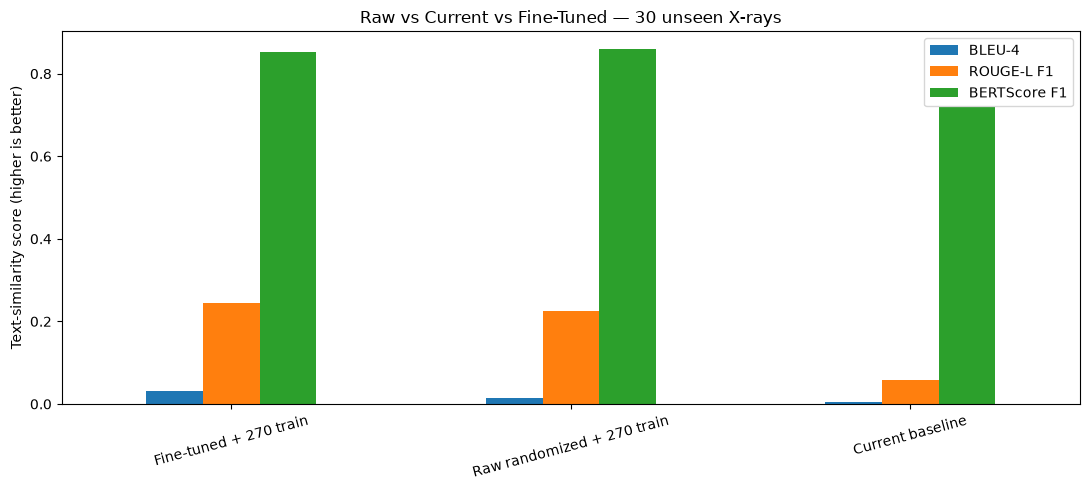

Saved: c:\Users\danik\Desktop\Проекты\Medical Image\blip_3_model_comparison\results\model_metric_comparison.png


In [14]:

plot_df = metrics_summary.set_index("Model")[
    ["BLEU-4", "ROUGE-L F1", "BERTScore F1"]
]

ax = plot_df.plot(kind="bar", figsize=(11, 5))
ax.set_title("Raw vs Current vs Fine-Tuned — 30 unseen X-rays")
ax.set_ylabel("Text-similarity score (higher is better)")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=15)
ax.legend(loc="best")
plt.tight_layout()

plot_path = RESULT_DIR / "model_metric_comparison.png"
plt.savefig(plot_path, dpi=180, bbox_inches="tight")
plt.show()

print("Saved:", plot_path)



## 10. Approximate winner statement

This cell deliberately uses **metric ranks**, rather than averaging BLEU, ROUGE and BERTScore raw values directly (their numerical scales are not equivalent).

The result is phrased as a **text-similarity result**, not a medical judgment.


In [15]:

best_row = metrics_summary.iloc[0]

print("=" * 90)
print("APPROXIMATE NON-CLINICAL RESULT")
print("=" * 90)
print(f"Best overall by mean rank across the 3 text-similarity metrics:")
print(f"  {best_row['Model']}")
print()
print(
    "Interpretation: on these 30 held-out examples, this model's generated reports "
    "are approximately the closest to the dataset reference reports according to "
    "BLEU-4, ROUGE-L and BERTScore."
)
print()
print(
    "This does NOT prove that the model is medically safest or diagnostically correct. "
    "A radiologist/clinical expert would be required for clinical evaluation."
)
print("=" * 90)


APPROXIMATE NON-CLINICAL RESULT
Best overall by mean rank across the 3 text-similarity metrics:
  Fine-tuned + 270 train

Interpretation: on these 30 held-out examples, this model's generated reports are approximately the closest to the dataset reference reports according to BLEU-4, ROUGE-L and BERTScore.

This does NOT prove that the model is medically safest or diagnostically correct. A radiologist/clinical expert would be required for clinical evaluation.



## 11. Inspect the actual outputs sample by sample

Use this section for the presentation/report. It lets us say things such as:

- whether the raw model produces broken/repetitive text;
- whether the current model produces coherent radiology-style language;
- whether fine-tuning makes outputs closer to the Indiana reference wording;
- where one model adds unsupported details or misses information.

Again, these are **qualitative observations**, not a medical diagnosis.


In [16]:

for i, row in comparison_df.iterrows():
    print("=" * 110)
    print(f"TEST SAMPLE {i+1:02d}/30")
    print(f"Image: {row['image']}")
    print(f"Dataset label: {row['y_label']}")
    print("-" * 110)

    print("\nREFERENCE REPORT:")
    print(row["y_report"])

    print("\nRAW / RANDOMIZED + TRAINED ON 270:")
    print(row["Raw_Randomized"])

    print("\nCURRENT BASELINE:")
    print(row["Current_Baseline"])

    print("\nFINE-TUNED + TRAINED ON 270:")
    print(row["Fine_Tuned"])

    print()


TEST SAMPLE 01/30
Image: 1971_IM-0633-1001.dcm.png
Dataset label: Normal
--------------------------------------------------------------------------------------------------------------

REFERENCE REPORT:
Stable heart size, mediastinal silhouette. No overt edema. No focal consolidation, pleural effusion or pneumothorax.

RAW / RANDOMIZED + TRAINED ON 270:
heart size normal. no pneumothorax or pleural effusion.

CURRENT BASELINE:
historyful - year - old female with shortness of breath and cough for five days, rule out cardiopulmonary process or congestive heart failureumonitisheezes hanging over the spine on chest x - rays done prior to graduation from zurich lady who presents with four hours of lightheadedness and left arm pain that started rolling out thirty minutes ago as well as half her left arm folded back onto her hipsposignsh while walking away from school friday nightmarlkout due to senior mandible knob grinder photo1040968247430

FINE-TUNED + TRAINED ON 270:
the heart is normal 


## 12. Optional human review sheet

Because we are not doctors, do **not** score “medical correctness”.

If the team wants a simple manual comparison, reviewers can score only surface-level properties such as:

- readability/coherence;
- obvious repetition;
- similarity to the supplied reference report;
- whether the output is empty/broken.

The blank columns below can be filled manually.


In [17]:

human_review = comparison_df[
    [
        "image",
        "y_label",
        "y_report",
        "Raw_Randomized",
        "Current_Baseline",
        "Fine_Tuned",
    ]
].copy()

human_review["Raw_coherence_1_to_5"] = ""
human_review["Baseline_coherence_1_to_5"] = ""
human_review["FineTuned_coherence_1_to_5"] = ""
human_review["Reviewer_notes"] = ""

review_path = RESULT_DIR / "human_review_30_template.csv"
human_review.to_csv(review_path, index=False)

display(human_review.head())
print("Saved:", review_path)


,image,y_label,y_report,Raw_Randomized,Current_Baseline,Fine_Tuned,Raw_coherence_1_to_5,Baseline_coherence_1_to_5,FineTuned_coherence_1_to_5,Reviewer_notes
0,1971_IM-0633-1001.dcm.png,Normal,"Stable heart size, mediastinal silhouette. No overt edema. No focal consolidation, pleural effusion or pneumothorax.",heart size normal. no pneumothorax or pleural effusion.,"historyful - year - old female with shortness of breath and cough for five days, rule out cardiopulmonary process or congestive heart failureumonitisheezes hanging over the spine on chest x - rays done prior to gradu...",the heart is normal in size. the mediastinal and hilar contours appear within normal limits. there is no pleural effusion or pneumothorax. the lungs appear clear.,,,,
1,3326_IM-1592-4004.dcm.png,Cardiomegaly,"Exam quality limited by hypoventilation and apical lordotic frontal projection. Considering technical factors heart size XXXX at XXXX mildly enlarged. No focal alveolar consolidation, no definite pleural effusion see...",heart size normal. no pneumothorax or pleural effusion.,"history 「 - year - old female with shortness of breath for five days and fevers and chills that are still dry cough for five days, rule out infectious process or fluid overloadheezergyess clarenceance to explain feve...",the heart is normal in size. the mediastinum is unremarkable. the lungs are clear. no pleural effusion or pneumothorax.,,,,
2,1811_IM-0525-1001.dcm.png,Cardiomegaly,"There is mild cardiomegaly and tortuous aorta. Mildly low lung volumes. No focal consolidation, pleural effusion, or pneumothorax. The XXXX XXXX are intact and without acute osseous abnormality. Mild degenerative cha...",heart size normal. no pneumothorax or pleural effusion.,"history 「 - year - old female with shortness of breath and bleach ingestion for five days, looking for hilar or mediastinal lymphadenoarthritis or kaposi ' s sarcoma vs cholecystectomyiettasis versus bacteremicjacent...","the heart size is within normal limits. there are small bilateral pleural effusions and bibasilar atelectasis, left greater than right. no focal consolidations or pneumothorax.",,,,
3,2162_IM-0779-1001.dcm.png,Cardiomegaly,"Frontal and lateral views of the chest show an unchanged cardiomediastinal silhouette. The cardiac silhouette remains moderately enlarged, exaggerated by epicardial fat pads. Interstitium is XXXX prominent. No XXXX f...",heart size normal. no pneumothorax or pleural effusion.,"history oceans - year - old female with cough and shortness of breath for five days, travel from in italychinnyman ' s disease care group person brought in after fall four days ago and left knee pain laughs while pla...","the lungs are clear without focal consolidation, effusion, or pneumothorax. cardiomediastinal silhouette is within normal limits. no free air below the right hemidiaphragm. osseous and soft tissue structures are unre...",,,,
4,123_IM-0153-4004.dcm.png,Cardiomegaly,Mild cardiomegaly. Tortuous aorta. No focal infiltrate. No pneumothorax or large pleural effusion. Soft tissue density identified in the medial right apex which is asymmetric compared to left.,heart size normal. no pneumothorax or pleural effusion.,"history oceans - year - old male with cough for five days and shortness of breath, rule out acute cardiopulmonary process or interstitial lung disease versus bronchioloarthrophiasis vs pneumonitis clarenceiaghoomaqui...",the heart is normal in size. the mediastinum is unremarkable. there is no pleural effusion or pneumothorax.,,,,


Saved: c:\Users\danik\Desktop\Проекты\Medical Image\blip_3_model_comparison\results\human_review_30_template.csv



# What to report in the project

A concise description for the experiment:

> We compared three variants of the same BLIP-based chest X-ray report generator on a fixed balanced subset of 300 Indiana Chest X-ray cases. A randomized-weight BLIP model and a fine-tuned pretrained BLIP model were trained on the same 270-image training split, while the existing pretrained model was kept unchanged as a baseline. All three models were evaluated on the same 30 held-out images (10 per target class). We compared generated reports against reference reports using BLEU-4, ROUGE-L, and BERTScore and inspected outputs qualitatively. The comparison is non-clinical and studies the effect of pretraining and project-specific fine-tuning rather than establishing diagnostic accuracy.

### Scientific question

**Does pretrained domain knowledge help compared with learning from only 270 local examples, and does additional fine-tuning on the project split increase similarity to held-out Indiana reference reports?**

### Important limitations

- The baseline checkpoint already contains substantial prior information from external chest X-ray/report data, while the randomized model sees only 270 local training examples.
- Therefore, the raw-vs-pretrained comparison is mainly an experiment about the value of **pretraining**, not a perfectly information-matched comparison.
- BLEU, ROUGE, and BERTScore measure textual similarity, not clinical correctness.
- Clinical claims would require evaluation by qualified medical experts.



## 13. Pack lightweight results

This creates a small ZIP with CSV/PNG experiment outputs only.  
Large BLIP checkpoints are intentionally excluded.


In [18]:

zip_base = WORK_DIR / "BLIP_3_Model_Comparison_RESULTS"

# shutil.make_archive appends .zip automatically.
zip_path = shutil.make_archive(
    str(zip_base),
    "zip",
    root_dir=RESULT_DIR,
)

print("✅ Results package:", zip_path)
print("\nResult files:")
for path in sorted(RESULT_DIR.iterdir()):
    print("-", path.name)


✅ Results package: c:\Users\danik\Desktop\Проекты\Medical Image\blip_3_model_comparison\BLIP_3_Model_Comparison_RESULTS.zip

Result files:
- baseline_outputs_30.csv
- comparison_all_30_outputs.csv
- comparison_all_30_outputs_with_metrics.csv
- finetune_training_history.csv
- finetuned_outputs_30.csv
- human_review_30_template.csv
- metrics_summary.csv
- model_metric_comparison.png
- raw_outputs_30.csv
- raw_training_history.csv
- report_test_30.csv
- report_train_270.csv
